# Figure 6 — Dissociation Between Engagement and Structural Reach Across Account Types

**Purpose:**
Prove that high engagement does NOT correlate with cross-community structural reach.
This is the key visualization for **Novelty 2** (small-account excitation effect).

**IMPORTANT — Post-Relabeling Framing:**
- This figure uses **categorical framing** (account type zones), NOT individual account annotation.
- Do NOT single out @barengwarga by name. The pattern is systemic across 11,426 nodes.
- Quadrant labels describe **zones** (e.g., 'High Visibility, Low Structural Impact') not individuals.

**Input files:**
- `actor_roles_classification.csv` — structural metrics per node (Analysis 3.2, post-relabeling)
- `Data_with_community2.csv` — tweet-level data with engagement metrics (post-relabeling)

**Output:**
- `actor_engagement_structural_merged.csv` — merged file for reuse
- `Figure6_engagement_vs_structural.png` — 300 DPI PNG
- `Figure6_engagement_vs_structural.pdf` — vector PDF for Elsevier submission

In [18]:
# =============================================================
# CELL 1 — Imports
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Journal-quality settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Imports OK')

Imports OK


In [19]:
# =============================================================
# CELL 2 — Load files & inspect columns
# =============================================================

# --- EDIT PATHS HERE if needed ---
PATH_ACTORS = 'actor_roles_classification2.csv'
PATH_BASE   = 'Data_with_community3.csv'

df_actors = pd.read_csv(PATH_ACTORS, sep=";")
df_base   = pd.read_csv(PATH_BASE, sep=";")

print(f'actor_roles_classification: {df_actors.shape[0]} rows, {df_actors.shape[1]} cols')
print(f'  Columns: {list(df_actors.columns)}')
print()
print(f'Data_with_community2: {df_base.shape[0]} rows, {df_base.shape[1]} cols')
print(f'  Columns: {list(df_base.columns)}')
print()

# Detect username column in base file
username_candidates = ['username', 'Username', 'user', 'screen_name', 'author']
username_col_base = None
for c in username_candidates:
    if c in df_base.columns:
        username_col_base = c
        break
print(f'Username column in base file: {username_col_base}')

# Detect cross-community column in actors file
cross_candidates = ['cross_comm_out', 'cross_community_out', 'cross_comm_edges',
                    'cross_community_edges', 'cross_comm_out_degree']
cross_col = None
for c in cross_candidates:
    if c in df_actors.columns:
        cross_col = c
        break
print(f'Cross-community column in actors file: {cross_col}')

if username_col_base is None or cross_col is None:
    print('\n⚠️  WARNING: Column not auto-detected. Check names above and set manually in Cell 3.')

actor_roles_classification: 11426 rows, 12 cols
  Columns: ['username', 'community', 'account_type', 'in_degree', 'out_degree', 'cross_comm_out', 'total_out', 'cross_comm_in', 'total_in', 'communities_reached_out', 'cross_ratio_out', 'structural_role']

Data_with_community2: 14248 rows, 28 cols
  Columns: ['date', 'is_quote', 'mentions', 'username', 'verified', 'account_type', 'full_text', 'tweet_url', 'quoted_url', 'view_count', 'quote_count', 'quoted_text', 'reply_count', 'display_name', 'retweet_count', 'favorite_count', 'in_reply_to_url', 'quoted_username', 'user_statuses_count', 'user_followers_count', 'user_following_count', 'in_reply_to_screen_name', 'topic', 'probability', 'topic_label', 'narrative', 'username_clean', 'community']

Username column in base file: username
Cross-community column in actors file: cross_comm_out


In [20]:
# =============================================================
# CELL 3 — Manual override (ONLY if Cell 2 shows WARNING)
# =============================================================
# Uncomment and set the correct column names if auto-detect failed:

# username_col_base = 'your_username_column_name'
# cross_col = 'your_cross_community_column_name'

In [21]:
# =============================================================
# CELL 4 — Aggregate engagement per user & merge
# =============================================================

# Step 1: Aggregate view_count per username from base dataset
# view_count is the primary engagement metric (retweet/reply/quote are zero-inflated)
engagement_cols = ['view_count', 'retweet_count', 'favorite_count', 'quote_count', 'reply_count']
eng_cols_available = [c for c in engagement_cols if c in df_base.columns]
print(f'Engagement columns found: {eng_cols_available}')

# Primary metric: view_count
if 'view_count' in df_base.columns:
    eng_per_user = df_base.groupby(username_col_base).agg(
        view_count_sum=('view_count', 'sum'),
        view_count_median=('view_count', 'median'),
        tweet_count=(username_col_base, 'count'),
    ).reset_index()
else:
    # Fallback: sum all available engagement metrics
    df_base['_total_eng'] = df_base[eng_cols_available].fillna(0).sum(axis=1)
    eng_per_user = df_base.groupby(username_col_base).agg(
        view_count_sum=('_total_eng', 'sum'),
        view_count_median=('_total_eng', 'median'),
        tweet_count=(username_col_base, 'count'),
    ).reset_index()
    print('⚠️  view_count not found, using sum of available engagement columns')

eng_per_user.rename(columns={username_col_base: 'username'}, inplace=True)
print(f'Engagement aggregated for {len(eng_per_user)} users')

# Step 2: Merge with actor roles
df_merged = df_actors.merge(eng_per_user, on='username', how='left')
df_merged['view_count_sum'] = df_merged['view_count_sum'].fillna(0)
print(f'Merged dataset: {len(df_merged)} rows')

# Step 3: Export for reuse
df_merged.to_csv('actor_engagement_structural_merged.csv', index=False)
print('\n✅ Saved: actor_engagement_structural_merged.csv')

# Quick sanity check
print(f'\n--- Sanity Check ---')
print(f'Nodes with view_count_sum > 0: {(df_merged["view_count_sum"] > 0).sum()}')
print(f'Nodes with {cross_col} > 0: {(df_merged[cross_col] > 0).sum()}')
print(f'Account types: {df_merged["account_type"].value_counts().to_dict()}')

Engagement columns found: ['view_count', 'retweet_count', 'favorite_count', 'quote_count', 'reply_count']
Engagement aggregated for 7586 users
Merged dataset: 11426 rows

✅ Saved: actor_engagement_structural_merged.csv

--- Sanity Check ---
Nodes with view_count_sum > 0: 0
Nodes with cross_comm_out > 0: 1010
Account types: {'grassroot': 11189, 'media/news': 120, 'elite/political': 117}


In [22]:
# Diagnosa merge issue
print("Sample username di actor_roles:")
print(df_actors['username'].head(10).tolist())
print()
print("Sample username di base dataset:")
print(df_base['username'].head(10).tolist())
print()

# Cek overlap
actors_users = set(df_actors['username'].dropna().str.strip().str.lower())
base_users = set(df_base['username'].dropna().str.strip().str.lower())
overlap = actors_users & base_users
print(f"Overlap setelah lowercase+strip: {len(overlap)} dari {len(actors_users)} actor nodes")

Sample username di actor_roles:
[' yang _tampan', 'joey_ardiva', ' yang gilang', 'tempodotco', ' yang mi3prnew', 'dpr_ri', 'prabowo', '007_atacante', 'ds_yantie', '00tiniwinibiti']

Sample username di base dataset:
['@solehudien30', '@k0dhar', '@ejijijis', '@rdh8tv', '@ropsable', '@rahmaniarbaftim', '@BudiBukanIntel', '@cactusown', '@ellagrossj', '@HouseMarici']

Overlap setelah lowercase+strip: 0 dari 11426 actor nodes


In [23]:
# Fix merge dengan cleaning username kedua sisi
df_actors['username_clean'] = df_actors['username'].str.strip().str.lower().str.lstrip('@')
df_base['username_clean_merge'] = df_base['username'].str.strip().str.lower().str.lstrip('@')

# Re-aggregate engagement
eng_per_user = df_base.groupby('username_clean_merge').agg(
    view_count_sum=('view_count', 'sum'),
    view_count_median=('view_count', 'median'),
    tweet_count=('username_clean_merge', 'count'),
).reset_index().rename(columns={'username_clean_merge': 'username_clean'})

# Re-merge
df_merged = df_actors.merge(eng_per_user, on='username_clean', how='left')
df_merged['view_count_sum'] = df_merged['view_count_sum'].fillna(0)

print(f"Merged: {len(df_merged)} rows")
print(f"Nodes with view_count_sum > 0: {(df_merged['view_count_sum'] > 0).sum()}")
print(f"Sample:\n{df_merged[['username', 'view_count_sum', 'cross_comm_out']].head(10)}")

Merged: 11426 rows
Nodes with view_count_sum > 0: 6365
Sample:
         username  view_count_sum  cross_comm_out
0    yang _tampan             0.0               0
1     joey_ardiva             0.0               0
2     yang gilang             0.0               0
3      tempodotco       3682390.0               0
4   yang mi3prnew             0.0               0
5          dpr_ri             0.0               0
6         prabowo             0.0               0
7    007_atacante           970.0               0
8       ds_yantie         66110.0               0
9  00tiniwinibiti           790.0               1


In [24]:
# =============================================================
# CELL 5 — Compute Spearman rho
# =============================================================

# Filter to nodes with at least some activity for meaningful correlation
# df_active = df_merged[(df_merged['view_count_sum'] > 0) & (df_merged[cross_col] >= 0)].copy()

# rho, p_val = spearmanr(df_active['view_count_sum'], df_active[cross_col])
# print(f'Spearman rho = {rho:.3f}')
# print(f'p-value = {p_val:.2e}')
# print(f'n = {len(df_active)}')
# print()
# print(f'Expected rho ~ 0.189 (from Analysis 3.2). If very different, check column mapping.')

# Re-run Spearman
from scipy.stats import spearmanr
import numpy as np

df_active = df_merged[(df_merged['view_count_sum'] > 0) & (df_merged['cross_comm_out'] >= 0)].copy()
rho, p_val = spearmanr(df_active['view_count_sum'], df_active['cross_comm_out'])
print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {p_val:.2e}")
print(f"n = {len(df_active)}")

# Prepare plot data
df_plot = df_merged[(df_merged['view_count_sum'] > 0) | (df_merged['cross_comm_out'] > 0)].copy()
df_plot['log_engagement'] = np.log10(df_plot['view_count_sum'].clip(lower=1))

acct_map = {
    'grassroot': 'Grassroots', 'grassroots': 'Grassroots',
    'media/news': 'Media/News', 'media': 'Media/News',
    'elite/political': 'Elite/Political', 'elite': 'Elite/Political',
}
df_plot['acct_label'] = df_plot['account_type'].str.strip().str.lower().map(acct_map).fillna('Other')

q_x = df_plot.loc[df_plot['view_count_sum'] > 0, 'log_engagement'].median()
q_y = df_plot.loc[df_plot['cross_comm_out'] > 0, 'cross_comm_out'].median()

print(f"\nQuadrant thresholds:")
print(f"  X median: {10**q_x:,.0f} views")
print(f"  Y median: {q_y:.1f} cross-community edges")
print(f"  Nodes in plot: {len(df_plot)}")

Spearman rho = 0.232
p-value = 8.73e-79
n = 6365

Quadrant thresholds:
  X median: 1,320 views
  Y median: 1.0 cross-community edges
  Nodes in plot: 6500


In [25]:
# # =============================================================
# # CELL 6 — Prepare plot data
# # =============================================================

# # Keep only nodes with any activity (engagement OR structural)
# df_plot = df_merged[
#     (df_merged['view_count_sum'] > 0) | (df_merged[cross_col] > 0)
# ].copy()

# # Log-transform engagement (many orders of magnitude)
# df_plot['log_engagement'] = np.log10(df_plot['view_count_sum'].clip(lower=1))

# # Normalize account_type labels for consistency
# acct_map = {
#     'grassroot': 'Grassroots',
#     'grassroots': 'Grassroots',
#     'media/news': 'Media/News',
#     'media': 'Media/News',
#     'elite/political': 'Elite/Political',
#     'elite': 'Elite/Political',
# }
# df_plot['acct_label'] = df_plot['account_type'].str.strip().str.lower().map(acct_map).fillna('Other')

# # Quadrant thresholds: use median of nodes with >0 values
# q_x = df_plot.loc[df_plot['view_count_sum'] > 0, 'log_engagement'].median()
# q_y = df_plot.loc[df_plot[cross_col] > 0, cross_col].median()

# print(f'Quadrant thresholds:')
# print(f'  X (log10 view_count): {q_x:.2f} → raw: {10**q_x:,.0f} views')
# print(f'  Y ({cross_col}): {q_y:.1f} edges')
# print(f'  Nodes in plot: {len(df_plot)}')

# # Count nodes per quadrant
# for label, mask in [
#     ('Q1: High Eng / High Struct', (df_plot['log_engagement'] >= q_x) & (df_plot[cross_col] >= q_y)),
#     ('Q2: Low Eng / High Struct',  (df_plot['log_engagement'] <  q_x) & (df_plot[cross_col] >= q_y)),
#     ('Q3: Low Eng / Low Struct',   (df_plot['log_engagement'] <  q_x) & (df_plot[cross_col] <  q_y)),
#     ('Q4: High Eng / Low Struct',  (df_plot['log_engagement'] >= q_x) & (df_plot[cross_col] <  q_y)),
# ]:
#     sub = df_plot[mask]
#     acct_dist = sub['acct_label'].value_counts().to_dict()
#     print(f'  {label}: n={len(sub)}  {acct_dist}')

✅ Saved. 8 nodes clipped from y-axis.


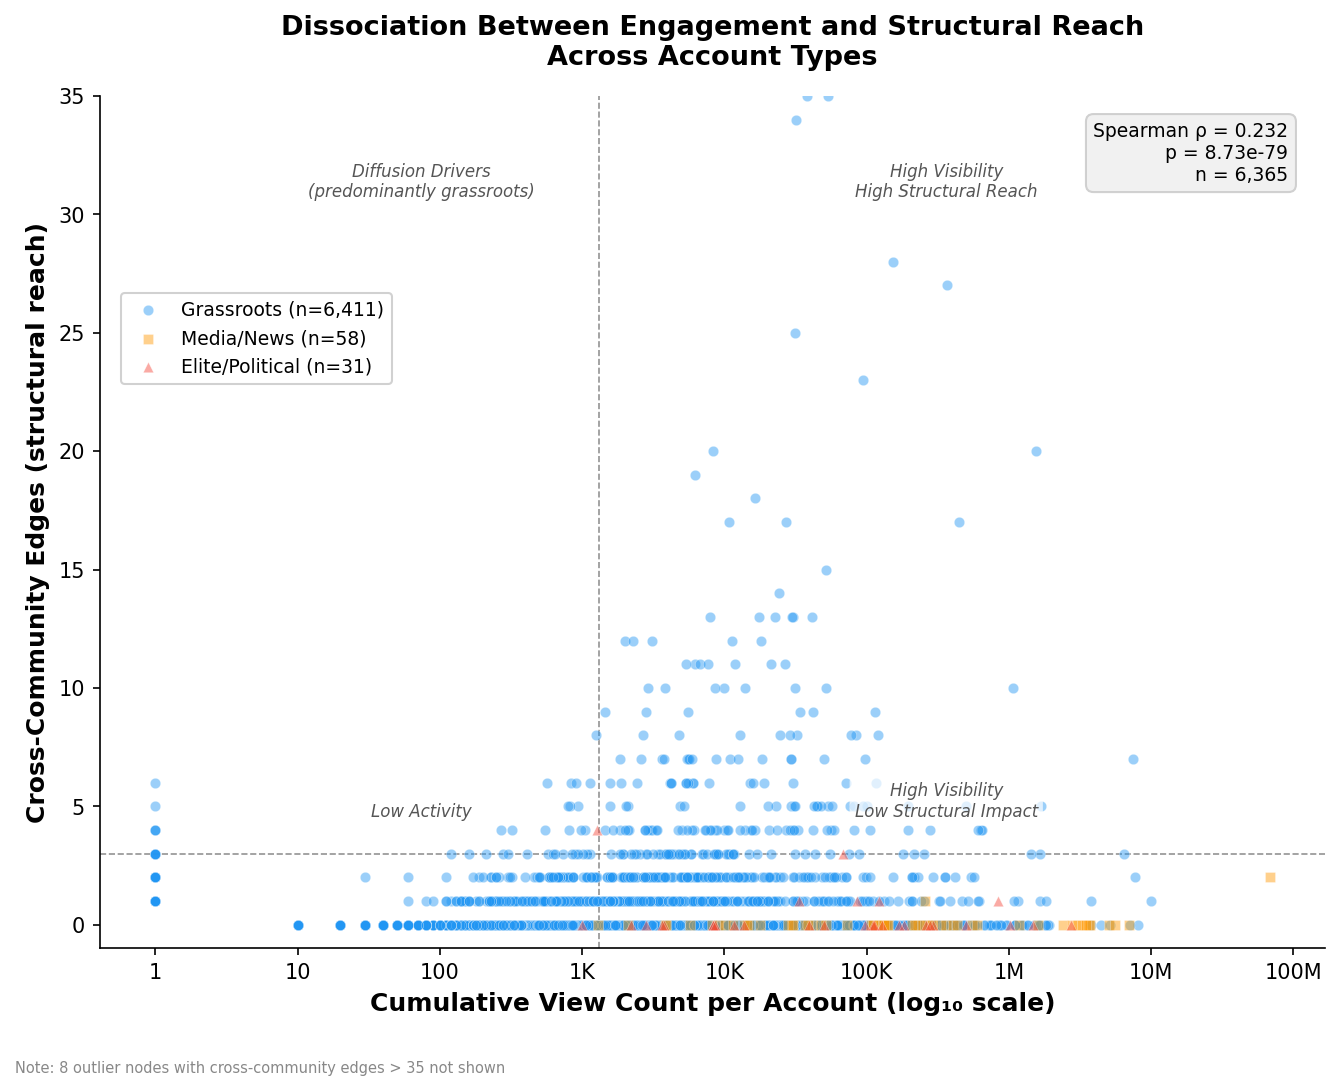

In [26]:
# =============================================================
# CELL 7 — MAIN FIGURE (Version A: Categorical Framing)
# =============================================================
#
# KEY DESIGN DECISIONS (post-relabeling):
# - NO individual account annotation (no @barengwarga name)
# - Quadrant ZONES are labeled, not individuals
# - Color by account_type to show categorical pattern
# - Spearman rho in bottom-right text box
#

# Color palette
# COLORS = {
#     'Grassroots':      '#2196F3',   # blue
#     'Media/News':      '#FF9800',   # orange
#     'Elite/Political': '#F44336',   # red
# }
# MARKERS = {
#     'Grassroots':      'o',
#     'Media/News':      's',  # square
#     'Elite/Political': '^',  # triangle
# }

# fig, ax = plt.subplots(figsize=(9, 7))

# # Plot each account type separately for clean legend
# for acct_label in ['Grassroots', 'Media/News', 'Elite/Political']:
#     subset = df_plot[df_plot['acct_label'] == acct_label]
#     if len(subset) == 0:
#         continue
#     ax.scatter(
#         subset['log_engagement'],
#         subset[cross_col],
#         c=COLORS.get(acct_label, '#999'),
#         marker=MARKERS.get(acct_label, 'o'),
#         s=25,
#         alpha=0.45,
#         edgecolors='white',
#         linewidths=0.3,
#         label=f'{acct_label} (n={len(subset):,})',
#         zorder=3,
#     )

# # --- Quadrant lines ---
# ax.axhline(y=q_y, color='#666', linestyle='--', linewidth=0.8, alpha=0.7, zorder=2)
# ax.axvline(x=q_x, color='#666', linestyle='--', linewidth=0.8, alpha=0.7, zorder=2)

# # --- Quadrant zone labels ---
# x_min, x_max = ax.get_xlim()
# y_min, y_max = ax.get_ylim()
# pad = 0.02  # relative padding from quadrant line

# zone_labels = [
#     # (x_pos, y_pos, text, horizontal_align, vertical_align)
#     (q_x + (x_max - q_x) * 0.5, y_max * 0.92,
#      'High Visibility\nHigh Structural Reach', 'center', 'top'),
#     (q_x - (q_x - x_min) * 0.5, y_max * 0.92,
#      'Diffusion Drivers\n(predominantly grassroots)', 'center', 'top'),
#     (q_x - (q_x - x_min) * 0.5, y_min + (q_y - y_min) * 0.1,
#      'Low Activity', 'center', 'bottom'),
#     (q_x + (x_max - q_x) * 0.5, y_min + (q_y - y_min) * 0.1,
#      'High Visibility, Low Structural Impact\n(predominantly media/news & elite)', 'center', 'bottom'),
# ]

# for (zx, zy, ztxt, zha, zva) in zone_labels:
#     ax.text(zx, zy, ztxt,
#             fontsize=8, fontstyle='italic', color='#555',
#             ha=zha, va=zva,
#             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
#             zorder=5)

# # --- Spearman rho annotation box ---
# stats_text = f'Spearman \u03C1 = {rho:.3f}\np = {p_val:.2e}\nn = {len(df_active):,}'
# ax.text(0.97, 0.03, stats_text,
#         transform=ax.transAxes,
#         fontsize=9, verticalalignment='bottom', horizontalalignment='right',
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', edgecolor='#ccc', alpha=0.9),
#         zorder=6)

# # --- Axes labels ---
# ax.set_xlabel('Cumulative View Count per Account (log\u2081\u2080 scale)', fontweight='bold')
# ax.set_ylabel('Cross-Community Edges (structural reach)', fontweight='bold')

# # Format x-axis to show raw numbers
# def log_formatter(x, pos):
#     val = 10**x
#     if val >= 1e6:
#         return f'{val/1e6:.0f}M'
#     elif val >= 1e3:
#         return f'{val/1e3:.0f}K'
#     else:
#         return f'{val:.0f}'
# ax.xaxis.set_major_formatter(mticker.FuncFormatter(log_formatter))

# ax.legend(loc='upper left', framealpha=0.9, edgecolor='#ccc')
# ax.set_title('Dissociation Between Engagement and Structural Reach\nAcross Account Types',
#              fontweight='bold', pad=15)

# plt.tight_layout()

# # Save
# fig.savefig('Figure6_engagement_vs_structural.png', dpi=300, bbox_inches='tight')
# fig.savefig('Figure6_engagement_vs_structural.pdf', bbox_inches='tight')
# print('\n✅ Saved: Figure6_engagement_vs_structural.png')
# print('✅ Saved: Figure6_engagement_vs_structural.pdf')

# plt.show()

COLORS = {
    'Grassroots': '#2196F3',
    'Media/News': '#FF9800',
    'Elite/Political': '#F44336',
}
MARKERS = {
    'Grassroots': 'o',
    'Media/News': 's',
    'Elite/Political': '^',
}

fig, ax = plt.subplots(figsize=(9, 7))

for acct_label in ['Grassroots', 'Media/News', 'Elite/Political']:
    subset = df_plot[df_plot['acct_label'] == acct_label]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['log_engagement'], subset['cross_comm_out'],
        c=COLORS[acct_label], marker=MARKERS[acct_label],
        s=25, alpha=0.45, edgecolors='white', linewidths=0.3,
        label=f'{acct_label} (n={len(subset):,})', zorder=3,
    )

q_y = 3
ax.axhline(y=q_y, color='#666', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=q_x, color='#666', linestyle='--', linewidth=0.8, alpha=0.7)

# Cap y-axis to show bulk distribution clearly
y_cap = 35
ax.set_ylim(-1, y_cap)
n_clipped = (df_plot['cross_comm_out'] > y_cap).sum()

# Zone labels — repositioned to avoid legend overlap
zone_labels = [
    (q_x + (np.log10(1e8) - q_x) * 0.5, y_cap * 0.92,
     'High Visibility\nHigh Structural Reach', 'center', 'top'),
    (q_x - (q_x - 0) * 0.4, y_cap * 0.92,
     'Diffusion Drivers\n(predominantly grassroots)', 'center', 'top'),
    (q_x - (q_x - 0) * 0.4, q_y + y_cap * 0.04,
     'Low Activity', 'center', 'bottom'),
    (q_x + (np.log10(1e8) - q_x) * 0.5, q_y + y_cap * 0.04,
     'High Visibility\nLow Structural Impact', 'center', 'bottom'),
]

for (zx, zy, ztxt, zha, zva) in zone_labels:
    ax.text(zx, zy, ztxt, fontsize=8, fontstyle='italic', color='#555',
            ha=zha, va=zva,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
            zorder=5)

stats_text = f'Spearman ρ = {rho:.3f}\np = {p_val:.2e}\nn = {len(df_active):,}'
ax.text(0.97, 0.97, stats_text,
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', edgecolor='#ccc', alpha=0.9),
        zorder=6)

def log_formatter(x, pos):
    val = 10**x
    if val >= 1e6: return f'{val/1e6:.0f}M'
    elif val >= 1e3: return f'{val/1e3:.0f}K'
    else: return f'{val:.0f}'

ax.xaxis.set_major_formatter(mticker.FuncFormatter(log_formatter))
ax.set_xlabel('Cumulative View Count per Account (log₁₀ scale)', fontweight='bold')
ax.set_ylabel('Cross-Community Edges (structural reach)', fontweight='bold')
ax.set_title('Dissociation Between Engagement and Structural Reach\nAcross Account Types',
             fontweight='bold', pad=15)

# Legend bottom-left to avoid zone label overlap
ax.legend(loc='upper left', framealpha=0.9, edgecolor='#ccc',
          bbox_to_anchor=(0.01, 0.78))

# Note about clipped outliers
fig.text(0.01, -0.02, f'Note: {n_clipped} outlier nodes with cross-community edges > {y_cap} not shown',
         fontsize=7, color='#888', va='top')

plt.tight_layout()
fig.savefig('Figure6_engagement_vs_structural.png', dpi=300, bbox_inches='tight')
fig.savefig('Figure6_engagement_vs_structural.pdf', bbox_inches='tight')
print(f'✅ Saved. {n_clipped} nodes clipped from y-axis.')
plt.show()


✅ Saved: Figure6B_drivers_highlighted.png
✅ Saved: Figure6B_drivers_highlighted.pdf


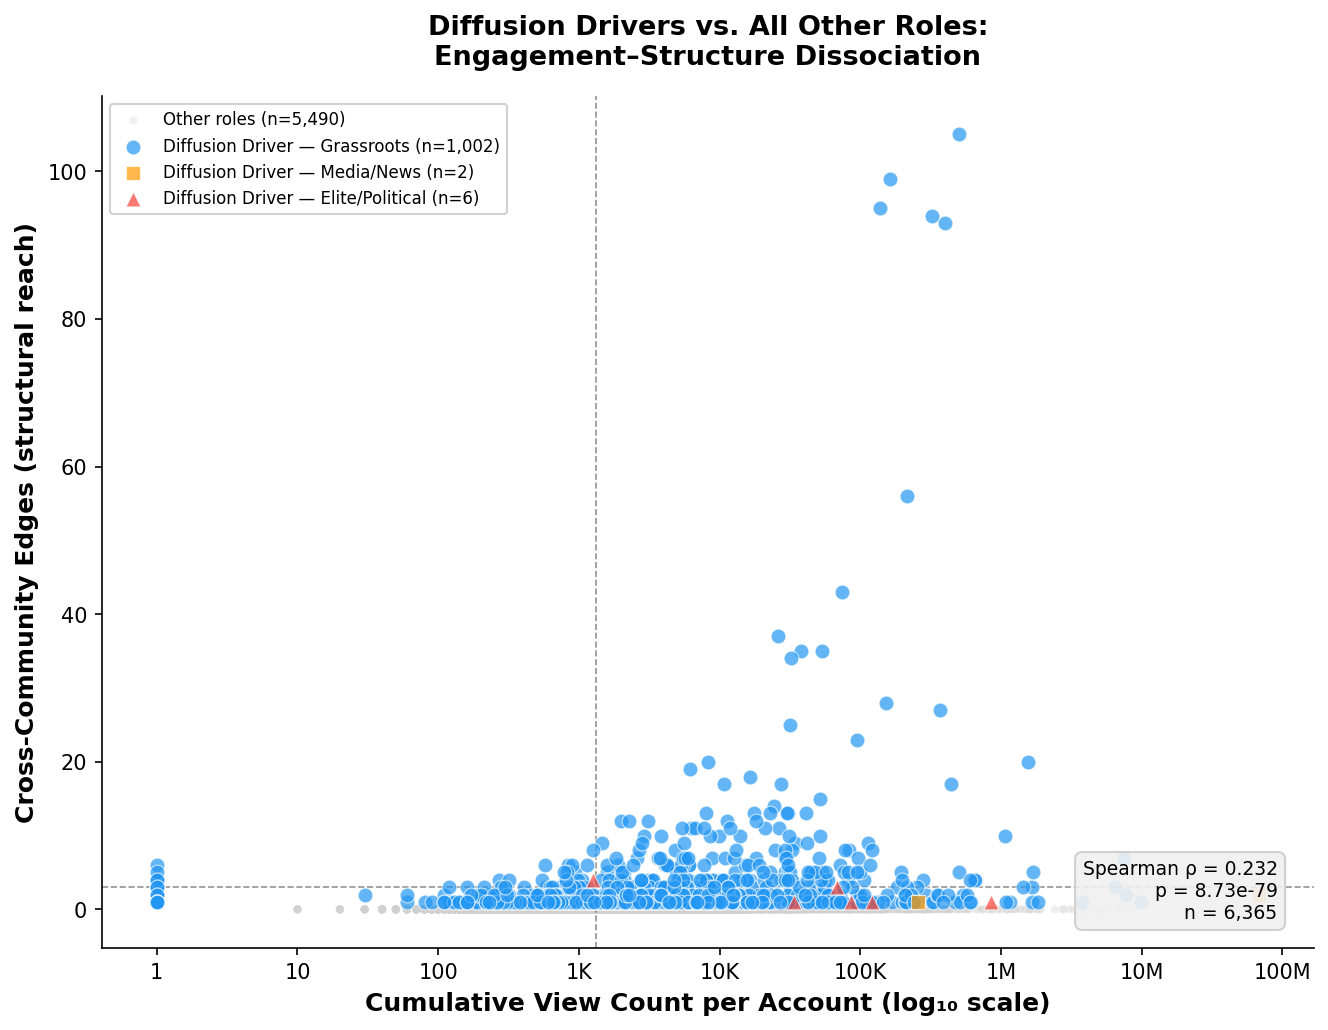

In [27]:
# =============================================================
# CELL 8 — Version B: Diffusion Drivers highlighted only
# =============================================================
# All nodes grey background, only Diffusion Drivers colored by account_type.
# Useful if you want sharper focus on RQ2 argument.

fig, ax = plt.subplots(figsize=(9, 7))

# Background: all non-driver nodes in grey
non_drivers = df_plot[df_plot.get('structural_role', '') != 'Diffusion Driver']
drivers = df_plot[df_plot.get('structural_role', '') == 'Diffusion Driver']

# Check if structural_role column exists
role_col_candidates = ['structural_role', 'role', 'actor_role']
role_col = None
for c in role_col_candidates:
    if c in df_plot.columns:
        role_col = c
        break

if role_col is None:
    print('⚠️  structural_role column not found. Skipping Version B.')
    print(f'Available columns: {list(df_plot.columns)}')
else:
    non_drivers = df_plot[df_plot[role_col] != 'Diffusion Driver']
    drivers = df_plot[df_plot[role_col] == 'Diffusion Driver']

    # Grey background
    ax.scatter(non_drivers['log_engagement'], non_drivers[cross_col],
               c='#d0d0d0', s=15, alpha=0.3, edgecolors='none',
               label=f'Other roles (n={len(non_drivers):,})', zorder=2)

    # Diffusion Drivers colored by account type
    for acct_label in ['Grassroots', 'Media/News', 'Elite/Political']:
        subset = drivers[drivers['acct_label'] == acct_label]
        if len(subset) == 0:
            continue
        ax.scatter(
            subset['log_engagement'], subset[cross_col],
            c=COLORS.get(acct_label, '#999'),
            marker=MARKERS.get(acct_label, 'o'),
            s=50, alpha=0.7,
            edgecolors='white', linewidths=0.5,
            label=f'Diffusion Driver — {acct_label} (n={len(subset):,})',
            zorder=4,
        )

    # Quadrant lines
    ax.axhline(y=q_y, color='#666', linestyle='--', linewidth=0.8, alpha=0.7, zorder=2)
    ax.axvline(x=q_x, color='#666', linestyle='--', linewidth=0.8, alpha=0.7, zorder=2)

    # Spearman box
    ax.text(0.97, 0.03, stats_text,
            transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', edgecolor='#ccc', alpha=0.9),
            zorder=6)

    ax.set_xlabel('Cumulative View Count per Account (log\u2081\u2080 scale)', fontweight='bold')
    ax.set_ylabel('Cross-Community Edges (structural reach)', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(log_formatter))
    ax.legend(loc='upper left', framealpha=0.9, edgecolor='#ccc', fontsize=8)
    ax.set_title('Diffusion Drivers vs. All Other Roles:\nEngagement–Structure Dissociation',
                 fontweight='bold', pad=15)

    plt.tight_layout()

    fig.savefig('Figure6B_drivers_highlighted.png', dpi=300, bbox_inches='tight')
    fig.savefig('Figure6B_drivers_highlighted.pdf', bbox_inches='tight')
    print('\n✅ Saved: Figure6B_drivers_highlighted.png')
    print('✅ Saved: Figure6B_drivers_highlighted.pdf')

    plt.show()

In [28]:
# =============================================================
# CELL 9 — Diagnostic: Top 5 accounts per quadrant
# =============================================================
# Use this to verify distribution patterns before finalizing.
# This cell is for YOUR reference only — not for the paper.

quadrants = {
    'Q1: High Eng / High Struct': (df_plot['log_engagement'] >= q_x) & (df_plot[cross_col] >= q_y),
    'Q2: Low Eng / High Struct':  (df_plot['log_engagement'] <  q_x) & (df_plot[cross_col] >= q_y),
    'Q3: Low Eng / Low Struct':   (df_plot['log_engagement'] <  q_x) & (df_plot[cross_col] <  q_y),
    'Q4: High Eng / Low Struct':  (df_plot['log_engagement'] >= q_x) & (df_plot[cross_col] <  q_y),
}

for qname, mask in quadrants.items():
    sub = df_plot[mask].sort_values('view_count_sum', ascending=False).head(5)
    print(f'\n=== {qname} ===')
    cols_to_show = ['username', 'account_type', 'view_count_sum', cross_col]
    if role_col:
        cols_to_show.append(role_col)
    cols_to_show = [c for c in cols_to_show if c in sub.columns]
    print(sub[cols_to_show].to_string(index=False))


=== Q1: High Eng / High Struct ===
       username account_type  view_count_sum  cross_comm_out  structural_role
     vdsyst3msx    grassroot       7446590.0               7 Diffusion Driver
 budibukanintel    grassroot       6490460.0               3 Diffusion Driver
ramaadamfaathir    grassroot       1677610.0               5 Diffusion Driver
   murtadhaone1    grassroot       1658170.0               3 Diffusion Driver
        srpablo    grassroot       1549320.0              20 Diffusion Driver

=== Q2: Low Eng / High Struct ===
       username    account_type  view_count_sum  cross_comm_out  structural_role
poldametrojaya_ elite/political          1270.0               4 Diffusion Driver
    fahmiasfame       grassroot          1260.0               8 Diffusion Driver
      _bsutanto       grassroot          1140.0               3 Diffusion Driver
  hendri_mantis       grassroot          1140.0               6 Diffusion Driver
eko_sri_wahyudi       grassroot          1080.0         

In [29]:
# =============================================================
# CELL 10 — Account type distribution per quadrant (for text)
# =============================================================
# This generates the exact percentages you can cite in the paper
# e.g., "X% of nodes in Q4 (high engagement, low structural) were media/news or elite"

print('Account type distribution per quadrant:')
print('=' * 70)

for qname, mask in quadrants.items():
    sub = df_plot[mask]
    total = len(sub)
    if total == 0:
        print(f'\n{qname}: empty')
        continue
    print(f'\n{qname} (n={total})')
    for acct_label in ['Grassroots', 'Media/News', 'Elite/Political']:
        n_acct = (sub['acct_label'] == acct_label).sum()
        pct = n_acct / total * 100
        print(f'  {acct_label}: {n_acct} ({pct:.1f}%)')

Account type distribution per quadrant:

Q1: High Eng / High Struct (n=232)
  Grassroots: 231 (99.6%)
  Media/News: 0 (0.0%)
  Elite/Political: 1 (0.4%)

Q2: Low Eng / High Struct (n=42)
  Grassroots: 41 (97.6%)
  Media/News: 0 (0.0%)
  Elite/Political: 1 (2.4%)

Q3: Low Eng / Low Struct (n=3262)
  Grassroots: 3260 (99.9%)
  Media/News: 1 (0.0%)
  Elite/Political: 1 (0.0%)

Q4: High Eng / Low Struct (n=2964)
  Grassroots: 2879 (97.1%)
  Media/News: 57 (1.9%)
  Elite/Political: 28 (0.9%)


In [30]:
# =============================================================
# CELL 11 — Auto-generate caption (copy-paste to draft)
# =============================================================
# Uses CATEGORICAL framing per post-relabeling correction.
# Does NOT mention @barengwarga by name.

# Count Q4 (high eng, low struct) composition
q4_mask = (df_plot['log_engagement'] >= q_x) & (df_plot[cross_col] < q_y)
q4_sub = df_plot[q4_mask]
q4_total = len(q4_sub)
q4_non_grassroot = ((q4_sub['acct_label'] == 'Media/News') | (q4_sub['acct_label'] == 'Elite/Political')).sum()
q4_non_grassroot_pct = q4_non_grassroot / q4_total * 100 if q4_total > 0 else 0

# Count Q2 (low eng, high struct) composition
q2_mask = (df_plot['log_engagement'] < q_x) & (df_plot[cross_col] >= q_y)
q2_sub = df_plot[q2_mask]
q2_total = len(q2_sub)
q2_grassroot = (q2_sub['acct_label'] == 'Grassroots').sum()
q2_grassroot_pct = q2_grassroot / q2_total * 100 if q2_total > 0 else 0

caption = f"""Figure 6. Dissociation between engagement intensity and structural reach \
across {len(df_plot):,} accounts in the protest diffusion network. \
Each point represents one account, colored by account type \
(blue = grassroots, orange = media/news, red = elite/political). \
Dashed lines indicate median thresholds for engagement ({10**q_x:,.0f} cumulative views) \
and structural reach ({q_y:.1f} cross-community edges), dividing the plot into four quadrants. \
The bottom-right quadrant (high engagement, low structural reach) is predominantly \
populated by media/news and elite accounts, while the top-left quadrant \
(low engagement, high structural reach) is dominated by grassroots accounts \
({q2_grassroot_pct:.1f}% grassroots). \
Spearman \u03C1 = {rho:.3f} (p = {p_val:.2e}, n = {len(df_active):,}) confirms the weak \
overall association between engagement and structural reach, supporting the finding \
that visibility and cross-community diffusion impact are empirically dissociated."""

print('--- CAPTION (copy-paste to draft) ---')
print()
print(caption)

--- CAPTION (copy-paste to draft) ---

Figure 6. Dissociation between engagement intensity and structural reach across 6,500 accounts in the protest diffusion network. Each point represents one account, colored by account type (blue = grassroots, orange = media/news, red = elite/political). Dashed lines indicate median thresholds for engagement (1,320 cumulative views) and structural reach (3.0 cross-community edges), dividing the plot into four quadrants. The bottom-right quadrant (high engagement, low structural reach) is predominantly populated by media/news and elite accounts, while the top-left quadrant (low engagement, high structural reach) is dominated by grassroots accounts (97.6% grassroots). Spearman ρ = 0.232 (p = 8.73e-79, n = 6,365) confirms the weak overall association between engagement and structural reach, supporting the finding that visibility and cross-community diffusion impact are empirically dissociated.


In [31]:
# Cek berapa persen nodes yang punya cross_comm_out >= 10
n_above = (df_merged['cross_comm_out'] >= 10).sum()
total = len(df_merged)
print(f"Nodes dengan cross_comm_out >= 10: {n_above} ({n_above/total*100:.1f}%)")
print(f"Nodes dengan cross_comm_out >= 5:  {(df_merged['cross_comm_out'] >= 5).sum()}")
print(f"Nodes dengan cross_comm_out >= 3:  {(df_merged['cross_comm_out'] >= 3).sum()}")
print(f"\nDistribusi cross_comm_out:")
print(df_merged['cross_comm_out'].describe())

Nodes dengan cross_comm_out >= 10: 50 (0.4%)
Nodes dengan cross_comm_out >= 5:  134
Nodes dengan cross_comm_out >= 3:  274

Distribusi cross_comm_out:
count    11426.000000
mean         0.285139
std          2.506552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        105.000000
Name: cross_comm_out, dtype: float64


In [32]:
for acct in ['Grassroots', 'Media/News', 'Elite/Political']:
    total = (df_plot['acct_label'] == acct).sum()
    in_q4 = ((df_plot['acct_label'] == acct) &
              (df_plot['log_engagement'] >= q_x) &
              (df_plot['cross_comm_out'] < q_y)).sum()
    print(f"{acct}: {in_q4}/{total} in Q4 ({in_q4/total*100:.1f}%)")

Grassroots: 2879/6411 in Q4 (44.9%)
Media/News: 57/58 in Q4 (98.3%)
Elite/Political: 28/31 in Q4 (90.3%)
